# A1.6 Regresión no lineal 

En esta actividad trabajaremos con una base de datos que generé en el semestre de Otoño 2022 
en  mi  clase  de  Sistemas  Digitales  en  la  Universidad  de  Monterrey.  En  dicha  materia,  cada 
semana se entregan actividades y la bandeja de entrega se cierra cada domingo a medianoche. 
Con mi experiencia impartiendo esta clase, tengo la sospecha de que entre más cerca de la hora 
de cierre de la bandeja se entrega la tarea, peor la calificación en la misma. Ayúdame a confirmar 
o rechazar mi hipótesis.  

Utilizaremos  el  archivo  de  nombre  “A1.6  Tiempo  de  Entrega.csv”,  donde  podrás  encontrar 
información para 432 actividades entregadas, organizadas de la siguiente manera: <br>
 “Tiempo”. Tiempo restante para que se cerrara la bandeja, en horas. Es decir, un 1 indica 
que entregaron la actividad el domingo a las 11:00 p.m., y un 48 indica que entregaron la 
actividad 48 horas antes del domingo a medianoche. <br>
 “Calificacion”. Calificación obtenida, en una escala entre el 0 y el 110.  

Desarrolla  los  siguientes  puntos  en  una Jupyter  Notebook,  tratando,  dentro  de  lo  posible,  que 
cada  punto  se  trabaje  en  una  celda  distinta.  Los  comentarios  en  el  código  siempre  son 
bienvenidos, de preferencia, aprovecha el markdown para generar cuadros de descripción que 
ayuden al lector a comprender el trabajo realizado.

1. Importa los datos del archivo “Tiempo de entrega.csv” a  tu  ambiente  de  trabajo.  Este 
archivo lo encontrarás en la misma página donde descargaste esta plantilla. Genera una 
gráfica de dispersión que muestre el comportamiento de los datos. Agrega una línea de 
texto en la que generes una predicción sobre qué tipo de algoritmo será el más adecuado 
para resolver la tarea (no hay respuestas correctas). 

i. NOTA: Si te encuentras con algo “raro”, te recomiendo que abras el archivo csv 
en Excel o alguna herramienta similar y revises qué podría estar causando el error. 
Cuando  lo  encuentres,  toma  alguna  acción  al  respecto  para  solucionar  el 
problema, e indica en la celda de la libreta la acción que tomaste y el por qué. No 
se evaluará la acción realizada, pero servirá para discusión en clase.

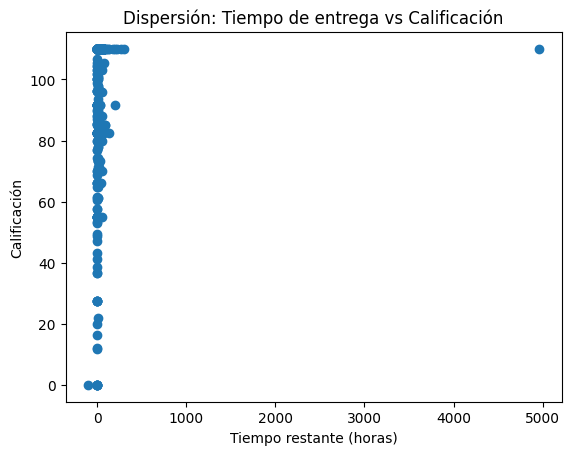

Se puede notar que dentro de los datos, hay tiempos negativos y uno extremadamente alto. También, hay valores que no son números. Se eliminaran estos valores atípicos.


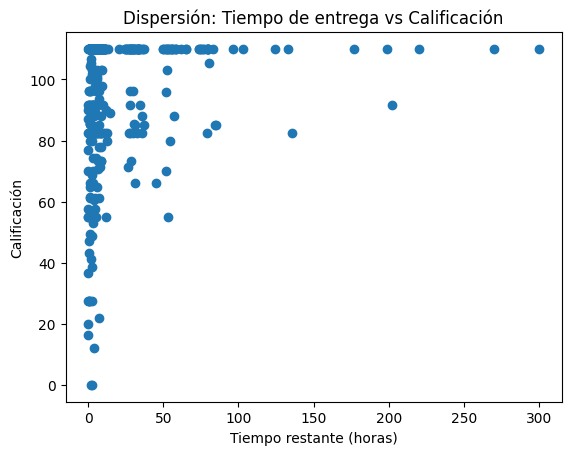

     Calificacion     Tiempo
0          85.000  85.076389
1          85.000  84.675556
2         110.000  79.553889
3         110.000  75.310556
4         110.000  64.958611
..            ...        ...
423        85.556   1.049167
424        61.112   1.018333
425       110.000   0.989167
426        85.556   0.953611
427       110.000   0.861111

[413 rows x 2 columns]


In [ ]:
import pandas as pd

df = pd.read_csv('A1.6 Tiempo de Entrega.csv')

import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(df['Tiempo'], pd.to_numeric(df['Calificacion'], errors='coerce'))
plt.xlabel('Tiempo restante (horas)')
plt.ylabel('Calificación')
plt.title('Dispersión: Tiempo de entrega vs Calificación')
plt.show()

print("Se puede notar que dentro de los datos, hay tiempos negativos y uno extremadamente alto. También, hay valores que no son números. Se eliminaran estos valores atípicos.")

df['Calificacion'] = pd.to_numeric(df['Calificacion'], errors='coerce')
df = df[df['Tiempo'].notna() & (df['Tiempo'] > 0) & (df['Tiempo'] <= 500)]
df = df[df['Calificacion'].notna()]

plt.scatter(df['Tiempo'], pd.to_numeric(df['Calificacion'], errors='coerce'))
plt.xlabel('Tiempo restante (horas)')
plt.ylabel('Calificación')
plt.title('Dispersión: Tiempo de entrega vs Calificación')
plt.show()

2. Separa  los  datos  en  entrenamiento  y  prueba,  con  una  relación  de  70/30.  Imprime  en 
consola el promedio de los tiempos en el conjunto de entrenamiento y en el conjunto de 
prueba. Haz lo mismo para las calificaciones. Incluye una línea de texto donde comentes 
sobre la similitud o diferencia de los valores promedio entre el conjunto de entrenamiento 
y el de validación, y cómo es que esto podría afectar al análisis. 

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, Y_train, Y_test = train_test_split(df['Tiempo'], df['Calificacion'], train_size=0.7)

print("Promedio Tiempo (entrenamiento):", X_train.mean())
print("Promedio Tiempo (prueba):", X_test.mean())
print("Promedio Calificación (entrenamiento):", Y_train.mean())
print("Promedio Calificación (prueba):", Y_test.mean())

print("Los promedios de las variables son diferentes, pero no son significativamente distintos como para afectar el análisis.")

Promedio Tiempo (entrenamiento): 17.618204536622837
Promedio Tiempo (prueba): 20.287598566217742
Promedio Calificación (entrenamiento): 96.91994031141869
Promedio Calificación (prueba): 95.38867870967742
Los promedios de las variables son diferentes, pero no son significativamente distintos como para afectar el análisis.


3. Entrena un modelo de regresión polinomial usando los datos de entrenamiento; puedes 
usar el orden de polinomial que consideres más adecuado. Imprime un resumen de los 
resultados  obtenidos  y  agrega  una  línea  de  texto  en  la  que  comentes  sobre  el  tipo  de 
relación (positiva o negativa; ¿a menor tiempo menor calificación?) entre el término lineal 
y la respuesta, lo que esto significa y si dicha variable está significativamente asociada 
con las calificaciones. 

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

# Entrenamiento de regresión polinomial de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
X_test_poly = poly.transform(X_test.values.reshape(-1, 1))

model_poly = LinearRegression()
model_poly.fit(X_train_poly, Y_train)

# Coeficientes del modelo
print("Coeficientes del modelo polinomial (grado 2):")
print(f"Intercepto: {model_poly.intercept_}")
print(f"Coeficientes: {model_poly.coef_}")

# R^2 en entrenamiento y prueba
print("R^2 entrenamiento:", model_poly.score(X_train_poly, Y_train))
print("R^2 prueba:", model_poly.score(X_test_poly, Y_test))

# Relación entre el término lineal y la calificación
print("El término lineal es positivo. Por lo tanto, a mayor tiempo, mayor calificación.")


print("El término lineal está significativamente asociado si su magnitud es considerable respecto al intercepto y el término cuadrático.")

Coeficientes del modelo polinomial (grado 2):
Intercepto: 94.02300715412335
Coeficientes: [ 0.          0.21059011 -0.0006155 ]
R^2 entrenamiento: 0.03638569113583623
R^2 prueba: 0.03628606270366985
El término lineal es positivo: a mayor tiempo, mayor calificación.
El término lineal está significativamente asociado si su magnitud es considerable respecto al intercepto y el término cuadrático.


4. Entrena un modelo de regresión segmentada, siguiendo la misma estrategia utilizada en 
la  lectura  interactiva,  utilizando  regresiones  cuadráticas  para  cada  segmento.  Genera 
estimaciones  (predicciones)  en  los  datos  de  validación.  Asegúrate  de  usar  la  función 
descrita en  la  lectura  interactiva,  instalándola en tu ambiente de trabajo en caso de no 
haberlo hecho previamente. 


RSE (modelo de regresión segmentada): 22.357211168627924


c:\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


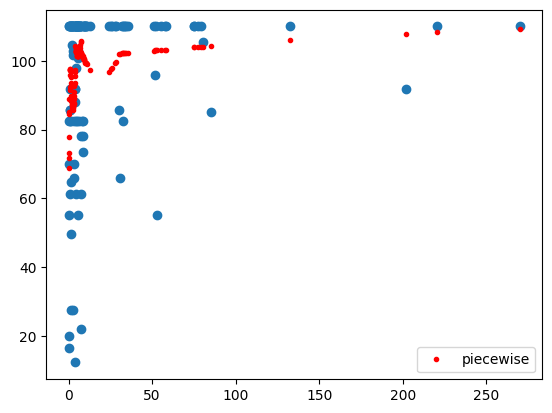

In [31]:
from mlinsights.mlmodel import PiecewiseRegressor

# Generar y entrenar modelo usando el término lineal y el cuadrático
ms = PiecewiseRegressor('bins').fit(X_train_poly[:, 1:], Y_train)

# Estimar el valor de Y en los datos de prueba
yHat_ms = ms.predict(X_test_poly[:, 1:])
# Calcular RSS
RSS_ms = sum((list(Y_test) - yHat_ms) ** 2)
# Calcular RSE
RSE_ms = np.sqrt(RSS_ms / (len(Y_test)-1))
# Imprimir resultado en pantalla
print("RSE (modelo de regresión segmentada):", RSE_ms)

plt.scatter(X_test, Y_test)
plt.plot(X_test, yHat_ms, "r.", label="piecewise")
plt.legend()

5. Entrena un modelo KNN para regresión utilizando el valor de k que consideres adecuado 
(o prueba con varios). Genera estimaciones en los datos de validación.

RSS (KNN): 61236.94143989083


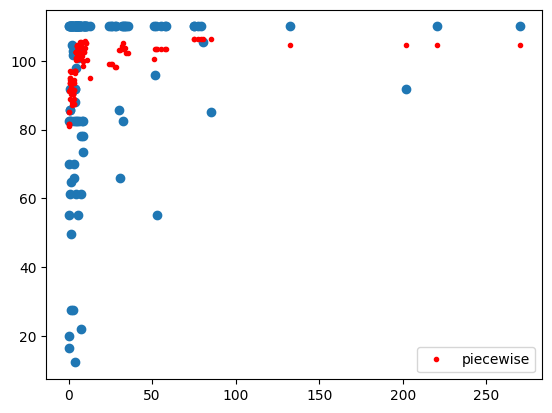

In [42]:
from sklearn.neighbors import KNeighborsRegressor as KNN
# Generar y entrenar modelo
mk = KNN(n_neighbors=15).fit(X_train.values.reshape(-1, 1), Y_train)

yHat_mk = mk.predict(X_test.values.reshape(-1, 1))
RSS_mk = sum((list(Y_test) - yHat_mk) ** 2)
RSE_mk = np.sqrt(RSS_mk / (len(Y_test)-1))

print("RSS (KNN):", RSS_mk)

plt.scatter(X_test, Y_test)
plt.plot(X_test, yHat_mk, "r.", label="piecewise")
plt.legend()

6. Calcula el RSE en los datos de prueba para los 3 modelos y agrega una línea de texto 
donde  comentes  sobre  sus  diferencias  y  si  hay  un  claro  “ganador”.  No  te  bases 
exclusivamente en el error, puedes considerar también aspectos como la interpretabilidad 
del modelo.

In [44]:
# RSE para modelo polinomial
yHat_poly = model_poly.predict(poly.transform(X_test.values.reshape(-1, 1)))
RSS_poly = sum((Y_test - yHat_poly) ** 2)
RSE_poly = np.sqrt(RSS_poly / (len(Y_test) - 1))

# RSE para modelo segmentado
RSS_segmented = sum((Y_test - yHat_ms) ** 2)
RSE_segmented = np.sqrt(RSS_segmented / (len(Y_test) - 1))

# RSE para modelo KNN (ya calculado previamente)
print("RSE (Regresión Polinomial):", RSE_poly)
print("RSE (Regresión Segmentada):", RSE_segmented)
print("RSE (KNN):", RSE_mk)

print("El modelo KNN tiene el menor RSE, pero la regresión polinomial y segmentada son más interpretables y muestran la relación entre tiempo y calificación. Si se busca interpretabilidad, los modelos polinomial y segmentado son preferibles; si se busca precisión, KNN es el ganador.")

RSE (Regresión Polinomial): 22.941343308772296
RSE (Regresión Segmentada): 22.35721116862793
RSE (KNN): 22.31280602074597
El modelo KNN tiene el menor RSE, pero la regresión polinomial y segmentada son más interpretables y muestran la relación entre tiempo y calificación. Si se busca interpretabilidad, los modelos polinomial y segmentado son preferibles; si se busca precisión, KNN es el ganador.


7. Para los datos de prueba, grafica tanto las calificaciones reales como las predichas por 
los 3 modelos en un mismo plot, asegurándote de utilizar etiquetas, colores y/o distintos 
marcadores para diferenciar y describir a cada modelo.

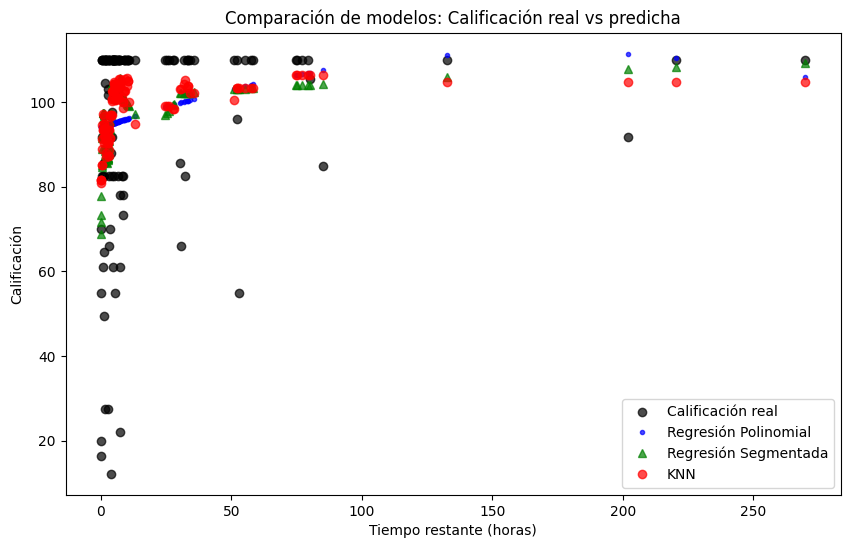

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, Y_test, color='black', label='Calificación real', alpha=0.7)
plt.plot(X_test, yHat_poly, 'b.', label='Regresión Polinomial', alpha=0.7)
plt.plot(X_test, yHat_ms, 'g^', label='Regresión Segmentada', alpha=0.7)
plt.plot(X_test, yHat_mk, 'ro', label='KNN', alpha=0.7)

plt.xlabel('Tiempo restante (horas)')
plt.ylabel('Calificación')
plt.title('Comparación de modelos: Calificación real vs predicha')
plt.legend()
plt.show()